# **IMPORT LIBRARIES**

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# **TOPIC**

> **Nén ảnh dùng Kmeans:** Nén ảnh sau để kích thước còn khoảng 25% kích thước ảnh ban đầu?

# **CODE HERE**

In [2]:
# Đường dẫn ảnh
img_path = "dog.jpg"

# Đọc ảnh
img = cv2.imread(img_path)

# Chuyển đổi ảnh từ BGR sang RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

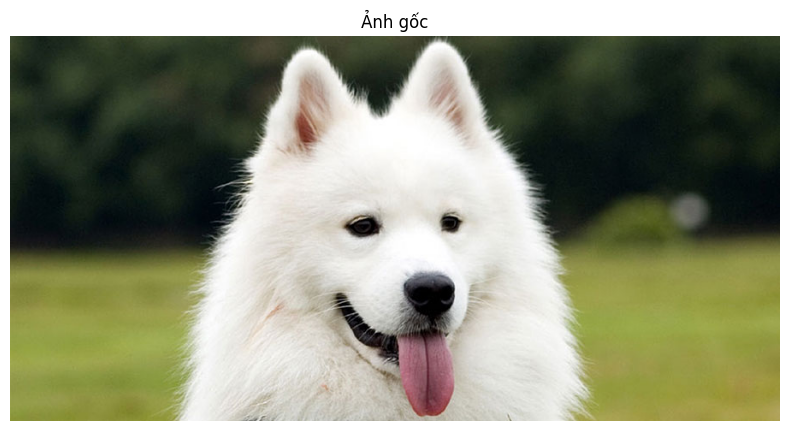

In [3]:
# Hiển thị ảnh
plt.figure(figsize=(8, 6))
plt.imshow(img_rgb)
plt.axis('off')
plt.title('Ảnh gốc')
plt.tight_layout()
plt.show()

In [4]:
# Chuyển thành dữ liệu N x 3
pixels = img_rgb.reshape(-1, 3)

In [5]:
# Chọn k = 64 để nén còn khoảng 25%
k = 64
kmeans = KMeans(n_clusters=k, random_state=42).fit(pixels)

In [6]:
# Tâm cụm (centroids)
centers = np.uint8(kmeans.cluster_centers_)

In [7]:
# Gán màu theo cụm
labels = kmeans.labels_
compressed_rgb = centers[labels].reshape(img_rgb.shape)

In [8]:
compressed_bgr = cv2.cvtColor(compressed_rgb, cv2.COLOR_RGB2BGR)
cv2.imwrite("compressed_k64.jpg", compressed_bgr)
cv2.imwrite("original.jpg", img)

True

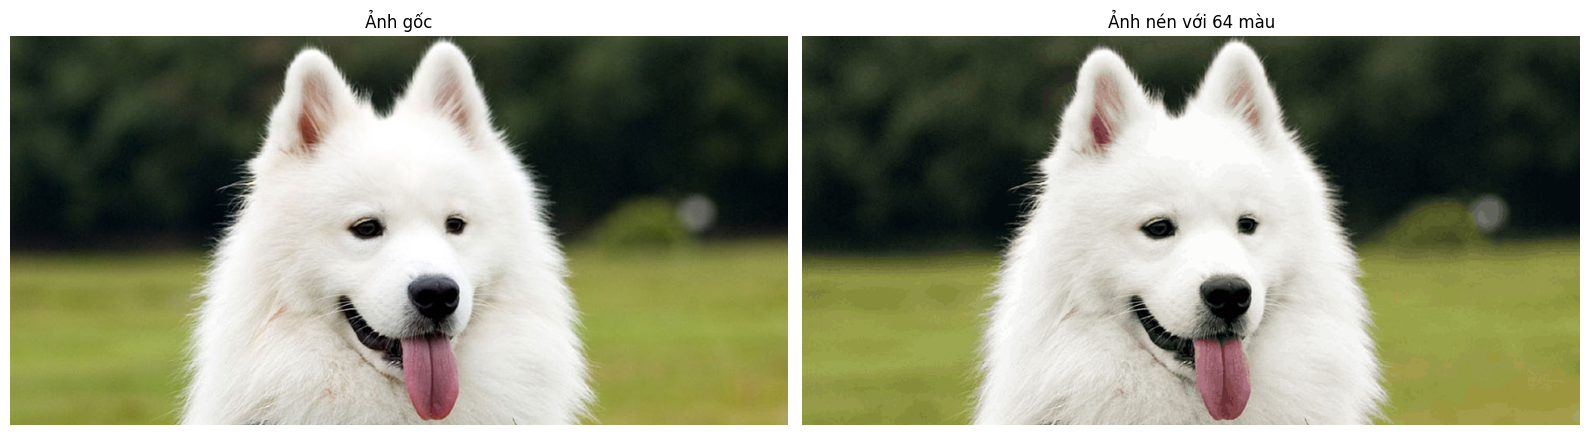

In [9]:
# Hiển thị ảnh gốc và ảnh nén
plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.axis('off')
plt.title('Ảnh gốc')
plt.subplot(1, 2, 2)
plt.imshow(compressed_rgb)
plt.axis('off')
plt.title(f'Ảnh nén với {k} màu')
plt.tight_layout()
plt.show()

## **CONCLUDE**

## 1. Mục đích
- Sử dụng thuật toán **K-means** để giảm số lượng màu của ảnh (color quantization).  
- Giảm bit/pixel từ 24 bit/pixel (ảnh RGB gốc) xuống còn 6 bit/pixel → dung lượng lý thuyết ≈ **25%** so với ảnh gốc.  
- Hiểu cách áp dụng K-means vào xử lý ảnh và nén dữ liệu.

## 2. Quy trình thực hiện
- Chuyển ảnh RGB 3D `(H, W, 3)` → mảng 2D `(H*W, 3)` bằng `reshape(-1, 3)` để K-means xử lý từng pixel.  
- Áp dụng K-means với **K = 64** (tương ứng 6 bit/pixel).  
- Gán mỗi pixel với màu centroid gần nhất.  
- Reshape lại về `(H, W, 3)` để tái tạo ảnh nén.

## 3. Lựa chọn K
- 1 pixel RGB gốc = 24 bit.  
- Muốn nén còn 25% → bit/pixel = 24 × 0.25 = 6 bit.  
- Số màu tối đa = 2⁶ = 64 → chọn **K = 64 màu**.  
- Lưu ý: K không bắt buộc là 2ⁿ, nhưng chọn 64 thuận tiện cho nén theo bảng màu (palette).

## 4. Đánh giá kết quả
- Ảnh nén còn **64 màu** → giảm dữ liệu, nhưng vẫn giữ hình dạng tổng thể.  
- Dung lượng lý thuyết:  
- File lưu ra (PNG/JPG) có thể khác dung lượng lý thuyết vì thuật toán nén ảnh.  
- Kiểm tra output:  
    + Số màu trong ảnh nén ≤ K  
    + Hình dạng tổng thể còn nhận diện được  
    + Dung lượng lý thuyết ≈ 25% dung lượng gốc

## 5. Kết luận tổng quát
- **K-means** là phương pháp giảm số màu hiệu quả, giảm dung lượng lý thuyết và dùng cho nén ảnh hoặc tiền xử lý dữ liệu hình ảnh.  
- Chọn **K dựa trên bit/pixel mong muốn**, không dựa trực tiếp vào số màu gốc × tỉ lệ nén.  
- File ảnh thực tế có thể lớn hơn ảnh gốc nếu lưu dưới JPG/PNG thông thường; để đạt dung lượng lý thuyết, cần lưu theo **indexed palette hoặc binary format**.